In [1]:
import numpy as np
import pandas as pd
import datetime
from sklearn import preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
%matplotlib inline

In [2]:
# make 8 blobs in 2D space
n_features = 2
centers = 8

X, y = make_blobs(n_samples=1000, centers=centers, n_features=n_features, random_state=68) #rand = 8, 42


df = pd.DataFrame(X, columns=[*[f'feature_{i}' for i in range(n_features)]])

# plot data
plt.figure(dpi=120)

x1 = df['feature_0']
x2 = df['feature_1']
plt.scatter(x1, x2)

plt.title("Figure 1")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

Text(0, 0.5, 'Feature 2')

In [3]:
df.head()

,feature_0,feature_1
0,-5.295432,-9.053238
1,2.058577,-5.251177
2,3.687847,9.551016
3,-3.914157,-8.430547
4,2.510445,9.198077


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

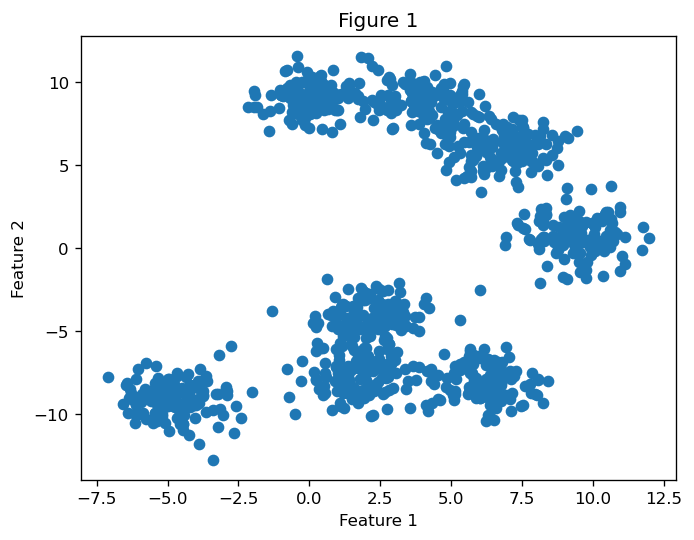

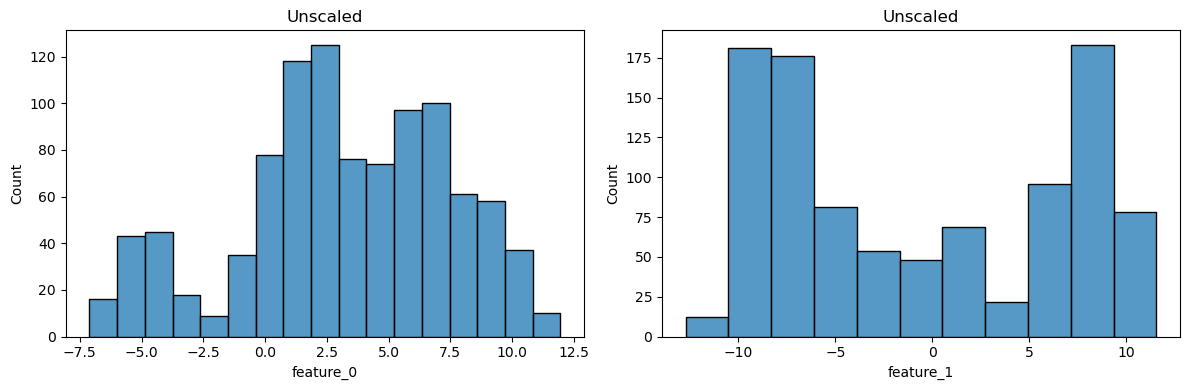

In [5]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df.iloc[:,0])
plt.title('Unscaled')
plt.gca().set_aspect('auto', adjustable='box')  # Adjust aspect ratio

plt.subplot(1,2,2)
sns.histplot(df.iloc[:,1])
plt.title('Unscaled')
plt.gca().set_aspect('auto', adjustable='box')  # Adjust aspect ratio

plt.tight_layout()
plt.show()

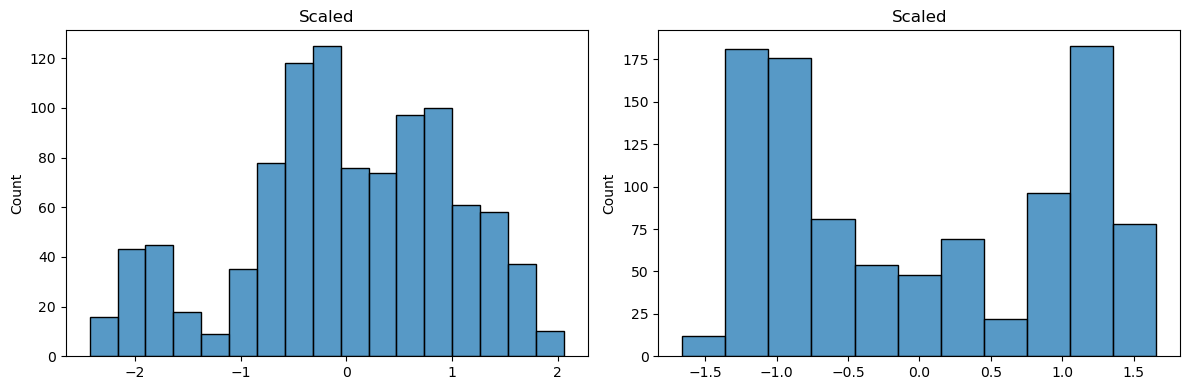

In [6]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(X_scaled[:,0])
plt.title('Scaled')
plt.gca().set_aspect('auto', adjustable='box')  # Adjust aspect ratio

plt.subplot(1,2,2)
sns.histplot(X_scaled[:,1])
plt.title('Scaled')
plt.gca().set_aspect('auto', adjustable='box')  # Adjust aspect ratio

plt.tight_layout()
plt.show()

In [7]:
from scipy.cluster.hierarchy import ward, dendrogram
import scipy.cluster.hierarchy as sch

In [8]:
help(sch.linkage)

Help on function linkage in module scipy.cluster.hierarchy:

linkage(y, method='single', metric='euclidean', optimal_ordering=False)
    Perform hierarchical/agglomerative clustering.

    The input y may be either a 1-D condensed distance matrix
    or a 2-D array of observation vectors.

    If y is a 1-D condensed distance matrix,
    then y must be a :math:`\binom{n}{2}` sized
    vector, where n is the number of original observations paired
    in the distance matrix. The behavior of this function is very
    similar to the MATLAB linkage function.

    A :math:`(n-1)` by 4 matrix ``Z`` is returned. At the
    :math:`i`-th iteration, clusters with indices ``Z[i, 0]`` and
    ``Z[i, 1]`` are combined to form cluster :math:`n + i`. A
    cluster with an index less than :math:`n` corresponds to one of
    the :math:`n` original observations. The distance between
    clusters ``Z[i, 0]`` and ``Z[i, 1]`` is given by ``Z[i, 2]``. The
    fourth value ``Z[i, 3]`` represents the number of

In [9]:
linkage_matrix = sch.linkage(X_scaled, method='average', metric='euclidean')

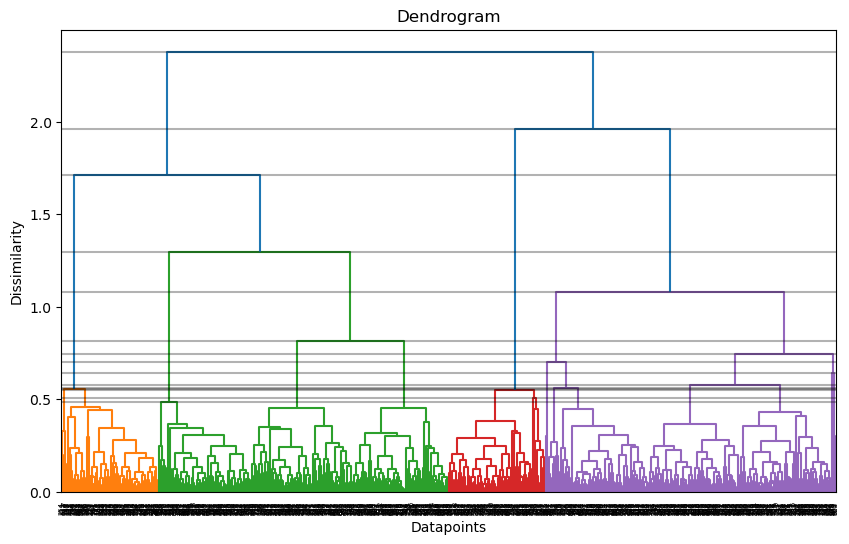

In [10]:
# Generate and plot dendrogram
plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(linkage_matrix)
z = linkage_matrix[:,2]

for i in range(1,16):
    rng = [z[-i],z[-i]]
    dom = [0,40000]
    plt.plot(dom,rng,'black', alpha=0.3)

plt.title('Dendrogram')
plt.xlabel('Datapoints')
plt.ylabel('Dissimilarity')

plt.show()

In [11]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
K = 4
hc = AgglomerativeClustering(n_clusters=K, linkage='average', metric='euclidean').fit(X_scaled)
df['cluster_label']  = hc.labels_
df['cluster_label'] = df['cluster_label'].astype('int64')

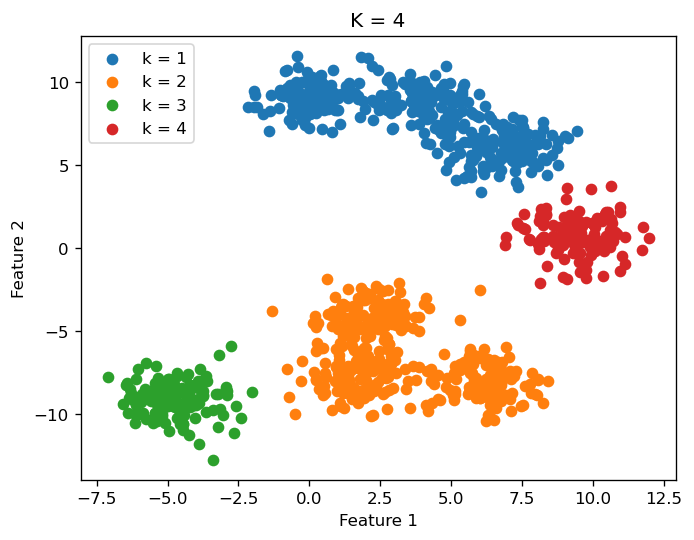

In [13]:
# plot data
plt.figure(dpi=120)
for k in range(K):
    x1 = df[df['cluster_label'] == k]['feature_0']
    x2 = df[df['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label="k = "+str(k+1))


plt.legend()
plt.title("K = 4")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [14]:
df.groupby('cluster_label').agg('median').T

cluster_label,0,1,2,3
feature_0,4.044795,2.643027,-4.798783,9.334918
feature_1,8.315352,-7.203017,-9.086992,0.676815


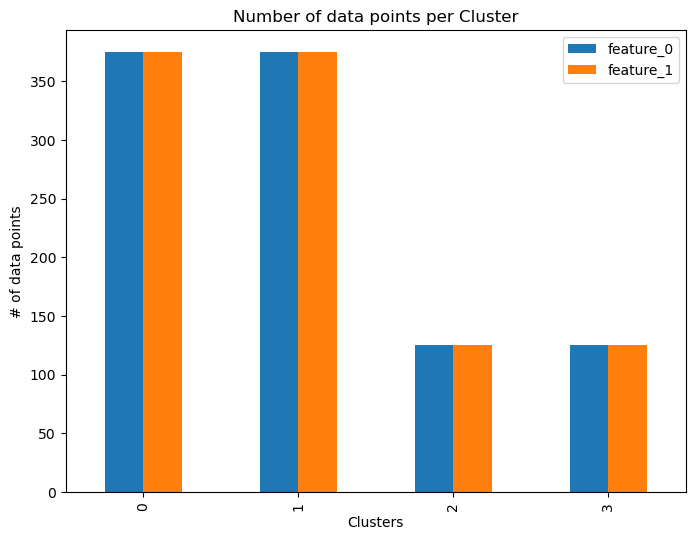

In [15]:
df.groupby(
    'cluster_label').count().reset_index().plot(kind='bar',
                                              x='cluster_label',
                                              figsize=(8,6),
                                              title='Number of data points per Cluster')
plt.xlabel("Clusters")
plt.ylabel("# of data points")
plt.show()